In [1]:
%load_ext autoreload
%autoreload 2

import os, sys 
sys.path.append("../models")
sys.path.append("../models/src_invariant")
sys.path.append("../models/src_plotting")
# !pip install qutip
from src_invariant.load_all import *
from src_plotting.load_all import *
from qutip import *
import numpy as np
import h5py
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from tqdm import tqdm

In [3]:
# Replicating figure 4 with Foley Equation
params = {
    'time': None,
    'steps': None,
    'base_coupling': None,
    'system_e_levels': None,
    'system_starts': None,
    'photon_starts': [0],
    'photon_freqs': [2],
    'photon_max_nums': [200],
    'spatial': False,
    'couplings': None,
    'positions': [],
    'model': 'pzw',
    'descr': ""
}

chain_length = 2
params['system_e_levels'] = np.array([[2, 0], [1, 0]])

mini = 0
maxi = 1.2
step = 0.01
eigenstates = 7

100%|██████████| 120/120 [00:20<00:00,  5.82it/s]


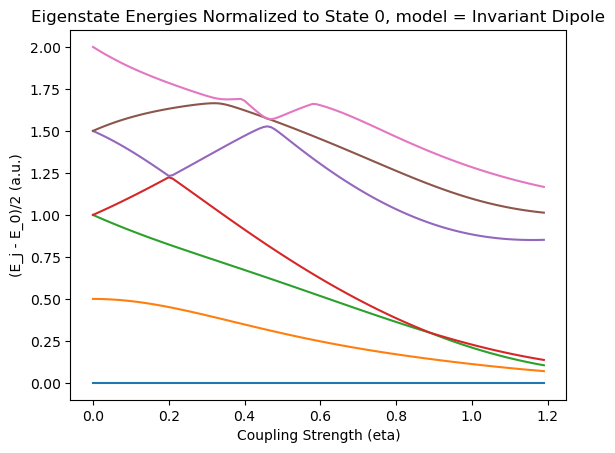

100%|██████████| 120/120 [00:19<00:00,  6.01it/s]


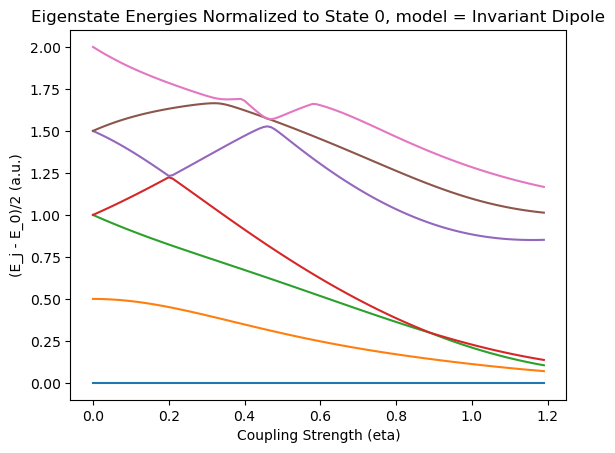

100%|██████████| 120/120 [00:21<00:00,  5.57it/s]


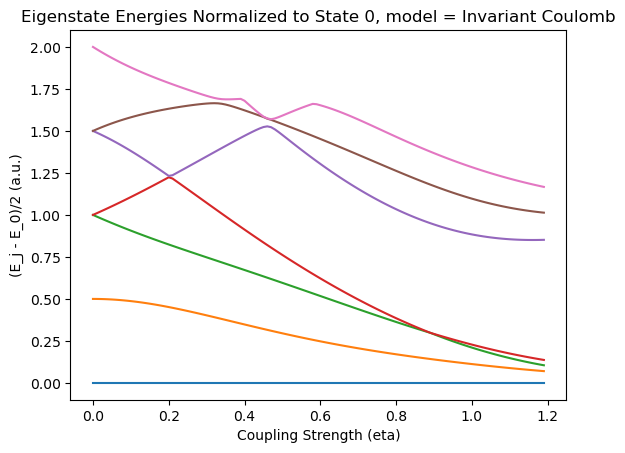

In [4]:
# Generalized Dicke model Fig 2

# params['model'] = 'invariant_dipole_minus'
# systems_dipole_minus = get_hamiltonians(params, chain_length, mini , maxi, step)
# # plot_energies(systems, [i for i in range(7)], min, max, step, xlabel = "Coupling Strength (eta)")
# plot_energies(systems_dipole_minus, [i for i in range(10)], mini, maxi, step, 
#               omega=params['photon_freqs'][0], norm_state = 0, xlabel = "Coupling Strength (eta)", model="Invariant Dipole")

params['model'] = 'invariant_dipole_plus'
systems_dipole_plus = get_hamiltonians(params, chain_length, mini , maxi, step)
# plot_energies(systems, [i for i in range(7)], min, max, step, xlabel = "Coupling Strength (eta)")
plot_energies(systems_dipole_plus, [i for i in range(eigenstates)], mini, maxi, step, 
              omega=params['photon_freqs'][0], norm_state = 0, xlabel = "Coupling Strength (eta)", model="Invariant Dipole")

params['model'] = 'invariant_dipole_pzw'
systems_dipole_pzw = get_hamiltonians(params, chain_length, mini , maxi, step)
# plot_energies(systems, [i for i in range(7)], min, max, step, xlabel = "Coupling Strength (eta)")
plot_energies(systems_dipole_plus, [i for i in range(eigenstates)], mini, maxi, step, 
              omega=params['photon_freqs'][0], norm_state = 0, xlabel = "Coupling Strength (eta)", model="Invariant Dipole")

# # Gauge Invariant Coulomb Model
params['model'] = 'invariant_coulomb'
systems_coulomb = get_hamiltonians(params, chain_length, mini , maxi, step)
# plot_energies(systems, [i for i in range(7)], min, max, step, xlabel = "Coupling Strength (eta)")
plot_energies(systems_coulomb, [i for i in range(eigenstates)], mini, maxi, step, 
              omega=params['photon_freqs'][0], norm_state = 0, xlabel = "Coupling Strength (eta)", model="Invariant Coulomb")

100%|██████████| 120/120 [00:20<00:00,  5.95it/s]


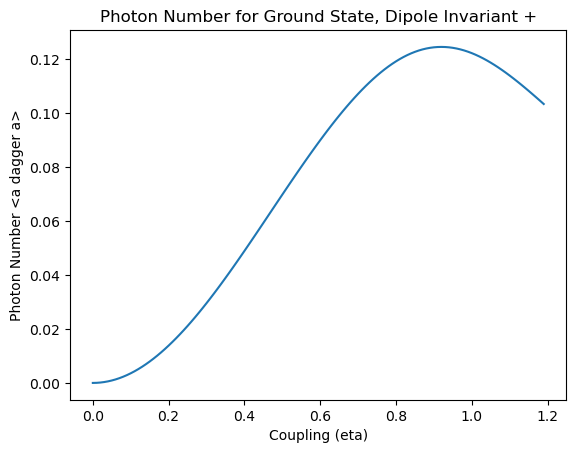

100%|██████████| 120/120 [01:08<00:00,  1.75it/s]


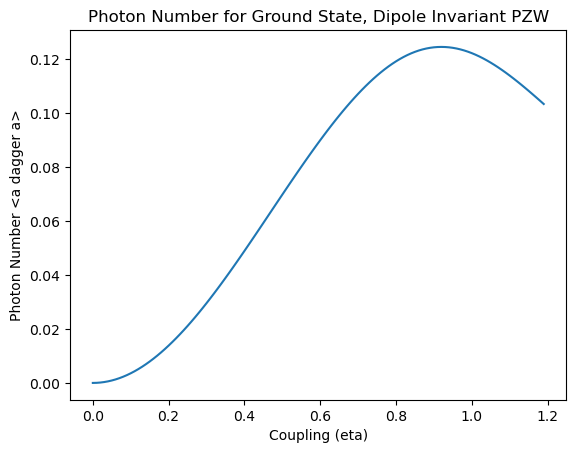

100%|██████████| 120/120 [00:21<00:00,  5.61it/s]


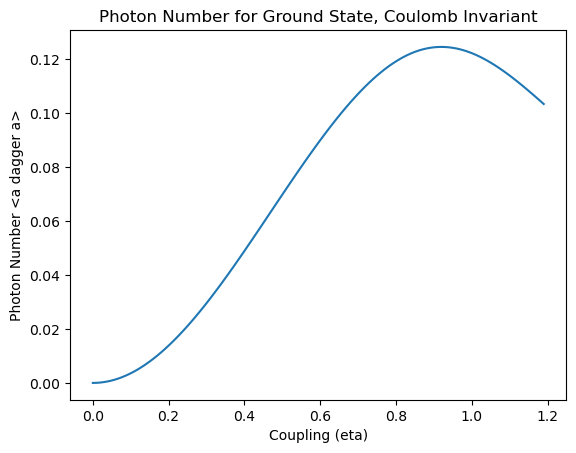

In [5]:
# plot_aa(systems_dipole_minus, 0, mini, maxi, step, 
#         xlabel = "Coupling (eta)", title = "Photon Number for Ground State, Dipole Invariant -")
plot_aa(systems_dipole_plus, 0, mini, maxi, step,
        xlabel = "Coupling (eta)", title = "Photon Number for Ground State, Dipole Invariant +")
plot_aa(systems_dipole_pzw, 0, mini, maxi, step,
        xlabel = "Coupling (eta)", title = "Photon Number for Ground State, Dipole Invariant PZW")
plot_aa(systems_coulomb, 0, mini, maxi, step,
        xlabel = "Coupling (eta)", title = "Photon Number for Ground State, Coulomb Invariant")

100%|██████████| 120/120 [01:12<00:00,  1.65it/s]


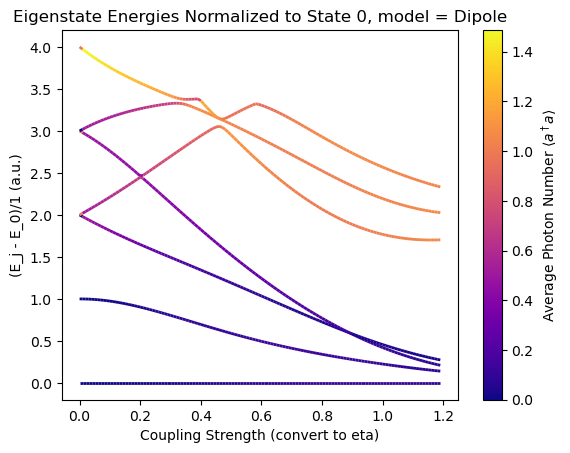

100%|██████████| 120/120 [07:41<00:00,  3.84s/it]


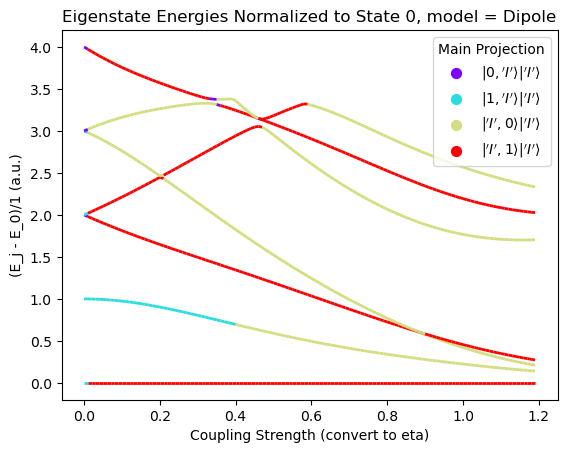

In [8]:
plot_polaritons(systems_dipole_pzw, [i for i in range(eigenstates)], mini, maxi, step, 
              omega=1, norm_state = 0,
                xlabel = "Coupling Strength (convert to eta)", model="Dipole", cmap='plasma')

plot_domstate(systems_dipole_pzw, [i for i in range(eigenstates)], mini, maxi, step, 
              omega=1, norm_state = 0,
                 xlabel = "Coupling Strength (convert to eta)", model="Dipole", cmap='rainbow')

100%|██████████| 120/120 [00:22<00:00,  5.31it/s]


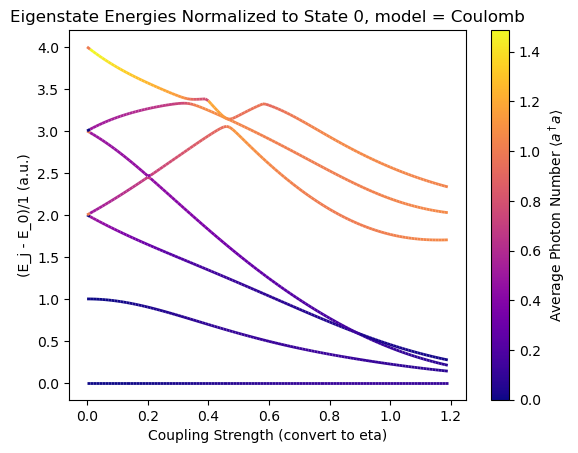

100%|██████████| 120/120 [01:10<00:00,  1.70it/s]


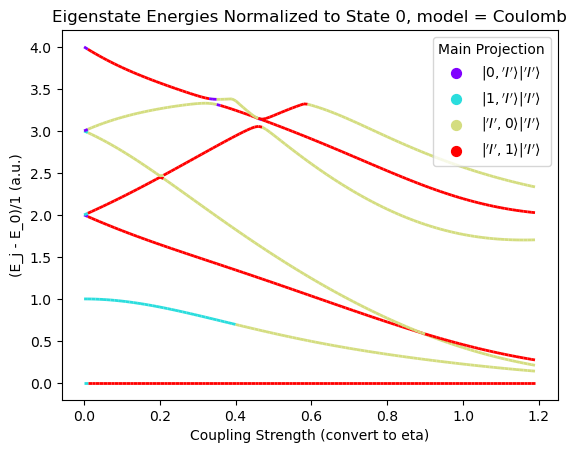

In [9]:
plot_polaritons(systems_coulomb, [i for i in range(eigenstates)], mini, maxi, step, 
              omega=1, norm_state = 0, 
                xlabel = "Coupling Strength (convert to eta)", model="Coulomb", cmap='plasma')

plot_domstate(systems_coulomb, [i for i in range(eigenstates)], mini, maxi, step, 
              omega=1, norm_state = 0,
                 xlabel = "Coupling Strength (convert to eta)", model="Coulomb", cmap='rainbow')